# Persona Validation Results — Visual Explanation

This notebook explains the validation results from the persona-based answer generation pipeline.

It is organized into four layers:

1. **Overall quality** — how well the system performs across all answers
2. **Question-level performance** — which questions are easier or harder to predict
3. **Persona-level variation** — which personas are modeled better or worse
4. **Group and trend alignment** — whether the model preserves patterns by age, gender, and education

The notebook expects these files in the same directory as the notebook, or you can override the paths in the setup cell:

- `validation_summary.json`
- `persona_metrics.csv`
- `question_metrics.csv`
- `group_metrics.csv`
- `group_question_metrics.csv`
- `trend_metrics.csv`
- `trend_detail.csv`


In [1]:

from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CANDIDATE_DIRS = [
    Path("."),
    Path.cwd(),
    Path("/mnt/data"),
]

REQUIRED_FILES = [
    "validation_summary.json",
    "persona_metrics.csv",
    "question_metrics.csv",
    "group_metrics.csv",
    "group_question_metrics.csv",
    "trend_metrics.csv",
    "trend_detail.csv",
]

def pick_base_dir(candidates, required_files):
    for candidate in candidates:
        candidate = candidate.resolve()
        if all((candidate / f).exists() for f in required_files):
            return candidate
    for candidate in candidates:
        candidate = candidate.resolve()
        print(f"Checked {candidate} -> {[ (candidate / f).exists() for f in required_files ]}")
    raise FileNotFoundError(
        "Could not find all required files. Put the notebook next to the validation outputs "
        "or edit CANDIDATE_DIRS / PATHS below."
    )

BASE_DIR = pick_base_dir(CANDIDATE_DIRS, REQUIRED_FILES)

PATHS = {
    "summary": BASE_DIR / "validation_summary.json",
    "persona": BASE_DIR / "persona_metrics.csv",
    "question": BASE_DIR / "question_metrics.csv",
    "group": BASE_DIR / "group_metrics.csv",
    "group_question": BASE_DIR / "group_question_metrics.csv",
    "trend": BASE_DIR / "trend_metrics.csv",
    "trend_detail": BASE_DIR / "trend_detail.csv",
}

print(f"Using BASE_DIR = {BASE_DIR}")
for name, path in PATHS.items():
    print(f"{name:>14}: {path} | exists={path.exists()}")

with open(PATHS["summary"], "r", encoding="utf-8") as f:
    summary = json.load(f)

persona_df = pd.read_csv(PATHS["persona"])
question_df = pd.read_csv(PATHS["question"])
group_df = pd.read_csv(PATHS["group"])
group_question_df = pd.read_csv(PATHS["group_question"])
trend_df = pd.read_csv(PATHS["trend"])
trend_detail_df = pd.read_csv(PATHS["trend_detail"])

overall = pd.Series(summary["overall"]).to_frame("value")
overall


Using BASE_DIR = /mnt/data
       summary: /mnt/data/validation_summary.json | exists=True
       persona: /mnt/data/persona_metrics.csv | exists=True
      question: /mnt/data/question_metrics.csv | exists=True
         group: /mnt/data/group_metrics.csv | exists=True
group_question: /mnt/data/group_question_metrics.csv | exists=True
         trend: /mnt/data/trend_metrics.csv | exists=True
  trend_detail: /mnt/data/trend_detail.csv | exists=True


,value
compared,6783.000000
exact_match,0.233525
macro_precision,0.220128
macro_recall,0.155276
macro_f1,0.153137
weighted_f1,0.238285
numeric_compared,6393.000000
mae,1.399812
rmse,1.865533
mean_actual,4.571093


## 1) Overall validation summary

These metrics describe the model across all compared answers.

How to read the main metrics:

- **Exact match / F1**: higher is better
- **MAE / RMSE**: lower is better
- **Bias**: closer to 0 is better
- **Pearson / Spearman**: higher is better
- **TVD / JS divergence**: lower is better

A useful reading pattern is:
- first check **exact match** and **weighted F1** for answer correctness,
- then check **RMSE** and **bias** for score realism,
- then check **Pearson/Spearman** for ranking consistency,
- then check **TVD/JS** for distribution similarity.


,Metric,Value
0,Compared answers,6783.0000
1,Exact match,0.2335
2,Weighted F1,0.2383
3,MAE,1.3998
4,RMSE,1.8655
5,Mean bias,-0.1075
6,Pearson,0.4640
7,Spearman,0.4672
8,TVD,0.2424
9,JS divergence,0.1034


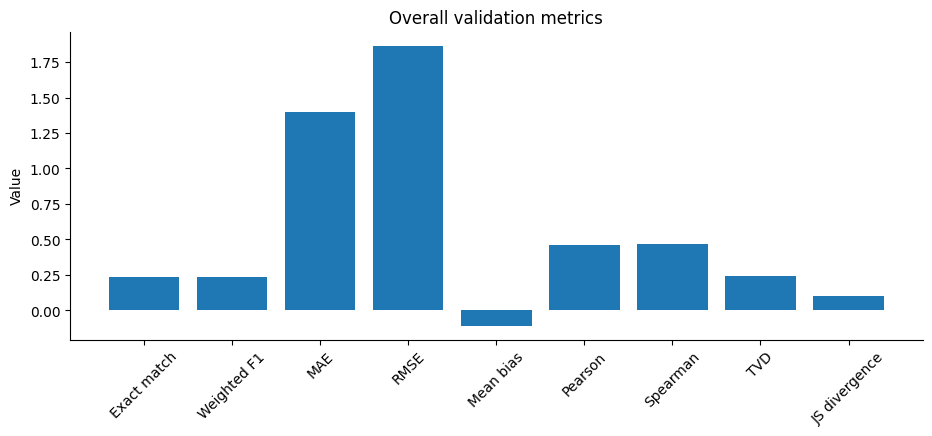

In [2]:

key_rows = [
    ("Compared answers", summary["overall"]["compared"]),
    ("Exact match", summary["overall"]["exact_match"]),
    ("Weighted F1", summary["overall"]["weighted_f1"]),
    ("MAE", summary["overall"]["mae"]),
    ("RMSE", summary["overall"]["rmse"]),
    ("Mean bias", summary["overall"]["mean_bias"]),
    ("Pearson", summary["overall"]["pearson"]),
    ("Spearman", summary["overall"]["spearman"]),
    ("TVD", summary["overall"]["tvd"]),
    ("JS divergence", summary["overall"]["js_divergence"]),
]
overall_table = pd.DataFrame(key_rows, columns=["Metric", "Value"])
display(overall_table.style.format({"Value": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(11, 4))
plot_df = overall_table.copy()
plot_df = plot_df[plot_df["Metric"] != "Compared answers"]
ax.bar(plot_df["Metric"], plot_df["Value"])
ax.set_title("Overall validation metrics")
ax.set_ylabel("Value")
ax.tick_params(axis="x", rotation=45)
plt.show()


## 2) Question-level performance

This section highlights where the model is strong and where it struggles.

Recommended interpretation:
- Use **exact match** and **weighted F1** to find the most and least predictable questions
- Use **RMSE** and **mean bias** to see whether the model systematically overshoots or undershoots
- Use **Pearson/Spearman** to see where the ordering of responses is preserved even when exact answers are not


In [3]:

display(question_df.sort_values("weighted_f1", ascending=False).reset_index(drop=True).style.format({
    "exact_match": "{:.3f}",
    "weighted_f1": "{:.3f}",
    "macro_f1": "{:.3f}",
    "mae": "{:.3f}",
    "rmse": "{:.3f}",
    "mean_bias": "{:.3f}",
    "pearson": "{:.3f}",
    "spearman": "{:.3f}",
    "tvd": "{:.3f}",
    "js_divergence": "{:.3f}",
}))

best_q = question_df.nlargest(5, "weighted_f1")[["question", "weighted_f1", "exact_match", "rmse"]]
worst_q = question_df.nsmallest(5, "weighted_f1")[["question", "weighted_f1", "exact_match", "rmse"]]

print("Best questions by weighted F1")
display(best_q.style.format({"weighted_f1": "{:.3f}", "exact_match": "{:.3f}", "rmse": "{:.3f}"}))

print("Worst questions by weighted F1")
display(worst_q.style.format({"weighted_f1": "{:.3f}", "exact_match": "{:.3f}", "rmse": "{:.3f}"}))


,question,compared,exact_match,macro_precision,macro_recall,macro_f1,weighted_f1,numeric_compared,mae,rmse,mean_actual,mean_predicted,mean_bias,pearson,spearman,tvd,js_divergence
0,Q31_1,399,0.414,0.276689,0.278699,0.275,0.394,399,1.068,1.675,5.293233,5.674185,0.381,0.401,0.426,0.103,0.030
1,Q31_2,398,0.364,0.223648,0.229246,0.225,0.359,398,1.085,1.626,5.457286,5.597990,0.141,0.379,0.403,0.106,0.027
2,Q24_5,399,0.358,0.337931,0.282749,0.274,0.334,399,1.236,1.855,4.626566,5.551378,0.925,0.613,0.574,0.190,0.049
3,Q27_1,399,0.328,0.194620,0.185752,0.164,0.312,399,0.950,1.325,5.969925,5.706767,-0.263,0.210,0.231,0.346,0.114
4,Q24_3,399,0.276,0.343921,0.275953,0.270,0.279,399,1.168,1.594,3.536341,4.052632,0.516,0.684,0.682,0.238,0.071
5,Q24_2,399,0.286,0.178649,0.204605,0.185,0.252,399,1.466,2.035,4.744361,5.453634,0.709,0.282,0.324,0.216,0.071
6,Q24_4,399,0.256,0.350132,0.235807,0.224,0.237,399,1.253,1.662,4.010025,4.375940,0.366,0.585,0.582,0.281,0.108
7,Q23_2,399,0.256,0.234661,0.184936,0.160,0.236,399,1.110,1.438,5.403509,4.934837,-0.469,0.372,0.382,0.253,0.108
8,Q31_3,399,0.198,0.406082,0.179191,0.161,0.180,399,1.361,1.731,4.817043,4.548872,-0.268,0.468,0.451,0.323,0.160
9,Q31_4,399,0.201,0.410668,0.204671,0.154,0.175,399,1.381,1.748,5.157895,4.493734,-0.664,0.434,0.437,0.393,0.206


Best questions by weighted F1


,question,weighted_f1,exact_match,rmse
12,Q31_1,0.394,0.414,1.675
13,Q31_2,0.359,0.364,1.626
7,Q24_5,0.334,0.358,1.855
8,Q27_1,0.312,0.328,1.325
5,Q24_3,0.279,0.276,1.594


Worst questions by weighted F1


,question,weighted_f1,exact_match,rmse
11,Q16,0.009,0.005,1.944
3,Q24_1,0.065,0.090,2.704
9,Q27_2,0.073,0.115,2.194
1,Q23_1,0.099,0.148,1.950
0,Q48,0.117,0.263,1.951


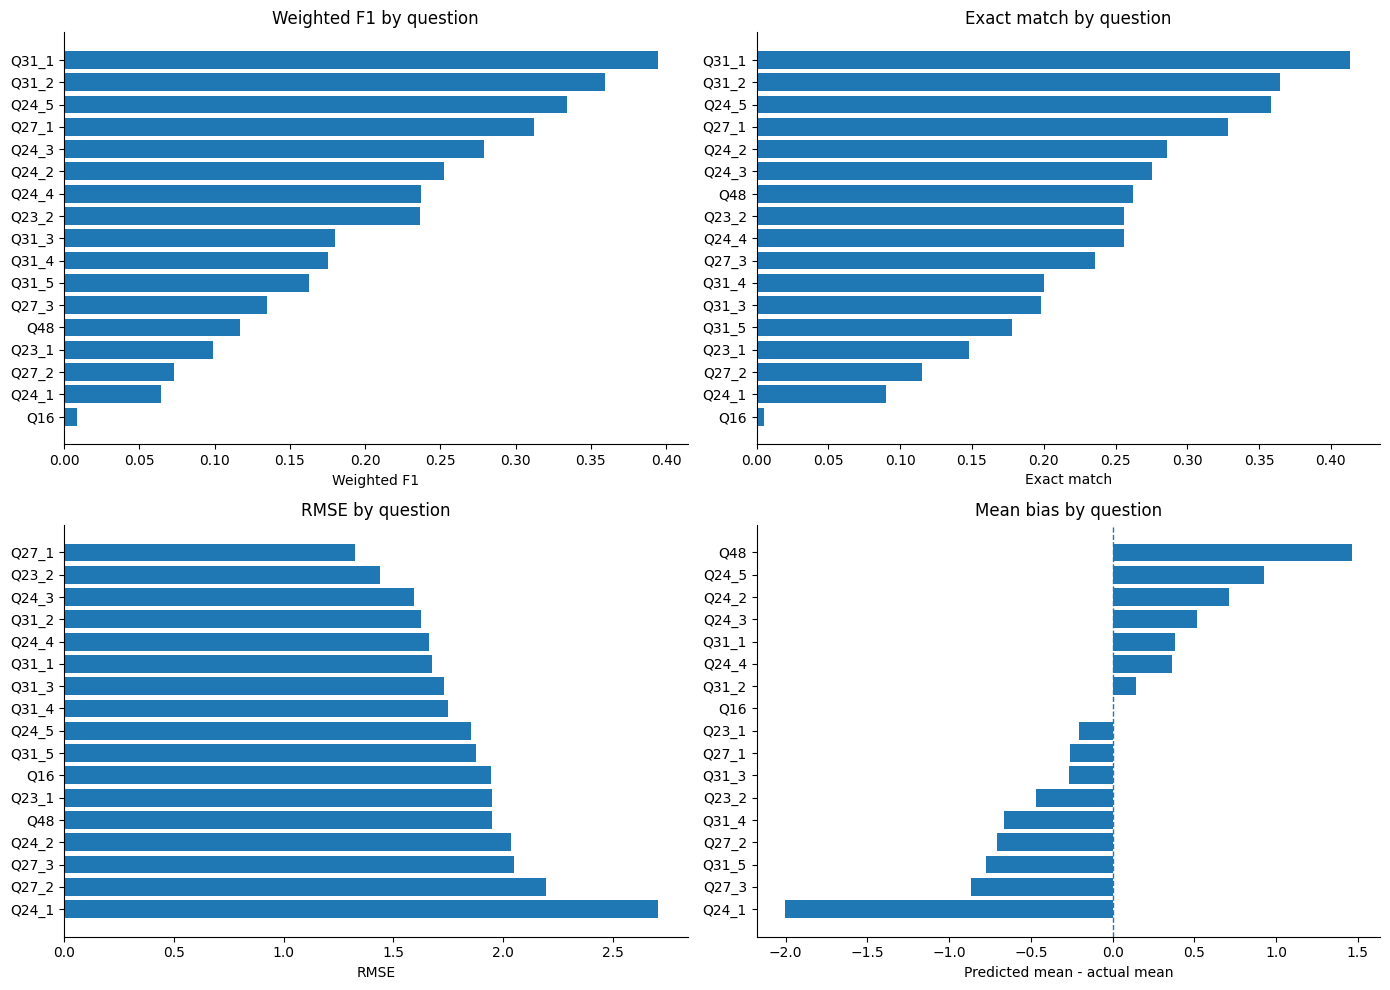

In [4]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

tmp = question_df.sort_values("weighted_f1", ascending=True)
axes[0, 0].barh(tmp["question"], tmp["weighted_f1"])
axes[0, 0].set_title("Weighted F1 by question")
axes[0, 0].set_xlabel("Weighted F1")

tmp = question_df.sort_values("exact_match", ascending=True)
axes[0, 1].barh(tmp["question"], tmp["exact_match"])
axes[0, 1].set_title("Exact match by question")
axes[0, 1].set_xlabel("Exact match")

tmp = question_df.sort_values("rmse", ascending=False)
axes[1, 0].barh(tmp["question"], tmp["rmse"])
axes[1, 0].set_title("RMSE by question")
axes[1, 0].set_xlabel("RMSE")

tmp = question_df.sort_values("mean_bias")
axes[1, 1].barh(tmp["question"], tmp["mean_bias"])
axes[1, 1].axvline(0, linestyle="--", linewidth=1)
axes[1, 1].set_title("Mean bias by question")
axes[1, 1].set_xlabel("Predicted mean - actual mean")

plt.tight_layout()
plt.show()


## 3) Persona-wise validation

This view answers a practical question:

**Are errors spread evenly across personas, or is performance highly uneven?**

What to look for:
- A wide RMSE spread means some personas are much harder to simulate than others
- A wide bias spread means some personas are systematically over- or under-predicted
- Grouped boxplots show whether errors are concentrated in specific demographic slices


,PersonaId,Q29,Q30,Q31,exact_match,weighted_f1,mae,rmse,mean_bias,pearson,spearman
0,1,25-34,Female,Master's degree or higher,0.411765,0.429412,1.1875,1.887459,-0.4375,-0.159948,-0.035327
1,2,25-34,Female,Bachelor's degree,0.117647,0.106952,1.6250,1.936492,0.6250,0.229416,0.111636
2,3,45-54,Other,Master's degree or higher,0.058824,0.078431,1.8750,2.263846,0.5000,0.011247,-0.182262
3,4,35-44,Female,Bachelor's degree,0.117647,0.134454,1.5625,1.920286,0.1875,0.105908,0.105953
4,5,35-44,Female,Master's degree or higher,0.294118,0.311765,1.1250,1.457738,0.3750,0.824281,0.750456


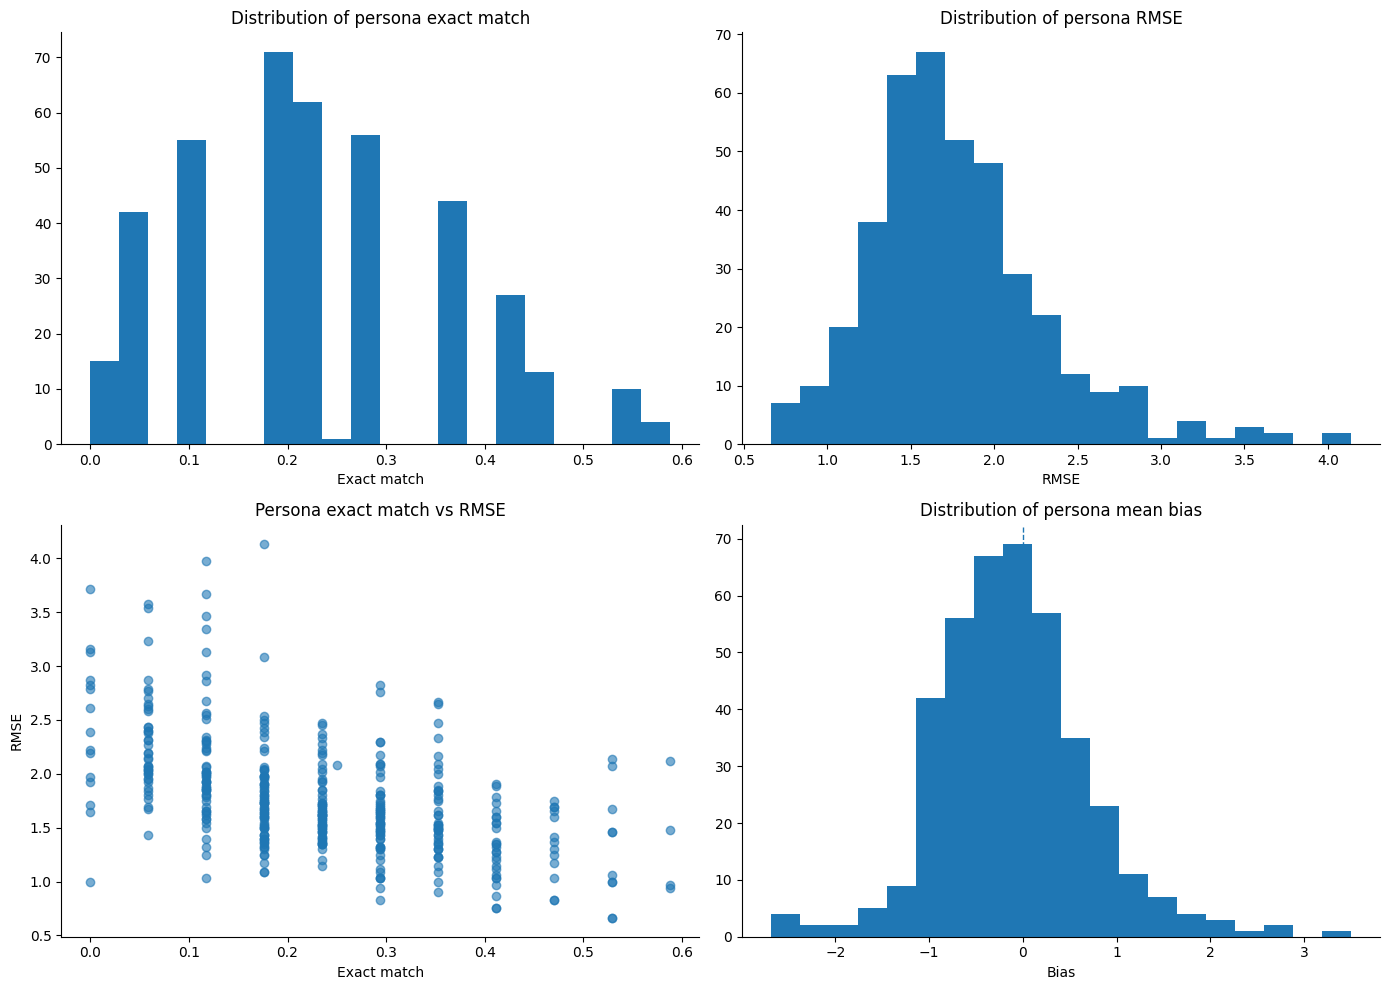

Best personas by exact match


,PersonaId,Q29,Q30,Q31,exact_match,weighted_f1,rmse
150,151,35-44,Male,Bachelor's degree,0.588,0.645,0.968
161,162,25-34,Male,High school or equivalent,0.588,0.707,1.479
202,203,55-64,Male,Master's degree or higher,0.588,0.724,2.121
247,248,45-54,Male,Bachelor's degree,0.588,0.565,0.935
46,47,55-64,Female,High school or equivalent,0.529,0.540,1.458
184,185,25-34,Male,Bachelor's degree,0.529,0.545,0.661
205,206,25-34,Female,Master's degree or higher,0.529,0.506,1.458
237,238,35-44,Female,Bachelor's degree,0.529,0.555,1.000
272,273,45-54,Female,Master's degree or higher,0.529,0.522,1.677
305,306,55-64,Female,Bachelor's degree,0.529,0.627,1.000


Worst personas by exact match


,PersonaId,Q29,Q30,Q31,exact_match,weighted_f1,rmse
29,30,35-44,Female,Bachelor's degree,0.000,0.000,2.194
51,52,45-54,Female,Bachelor's degree,0.000,0.000,2.385
60,61,55-64,Male,High school or equivalent,0.000,0.000,1.969
70,71,45-54,Female,Master's degree or higher,0.000,0.000,2.828
75,76,65+,Male,High school or equivalent,0.000,0.000,2.784
78,79,35-44,Male,High school or equivalent,0.000,0.000,1.645
93,94,25-34,Female,Master's degree or higher,0.000,0.000,1.714
250,251,nan,nan,nan,0.000,0.000,1.000
259,260,35-44,Male,Bachelor's degree,0.000,0.000,2.222
282,283,35-44,Female,High school or equivalent,0.000,0.000,3.717


In [5]:

metric_cols = ["exact_match", "weighted_f1", "mae", "rmse", "mean_bias", "pearson", "spearman"]
display(persona_df[["PersonaId", "Q29", "Q30", "Q31"] + metric_cols].head())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(persona_df["exact_match"].dropna(), bins=20)
axes[0, 0].set_title("Distribution of persona exact match")
axes[0, 0].set_xlabel("Exact match")

axes[0, 1].hist(persona_df["rmse"].dropna(), bins=20)
axes[0, 1].set_title("Distribution of persona RMSE")
axes[0, 1].set_xlabel("RMSE")

axes[1, 0].scatter(persona_df["exact_match"], persona_df["rmse"], alpha=0.6)
axes[1, 0].set_title("Persona exact match vs RMSE")
axes[1, 0].set_xlabel("Exact match")
axes[1, 0].set_ylabel("RMSE")

axes[1, 1].hist(persona_df["mean_bias"].dropna(), bins=20)
axes[1, 1].axvline(0, linestyle="--", linewidth=1)
axes[1, 1].set_title("Distribution of persona mean bias")
axes[1, 1].set_xlabel("Bias")

plt.tight_layout()
plt.show()

print("Best personas by exact match")
display(persona_df.nlargest(10, "exact_match")[["PersonaId", "Q29", "Q30", "Q31", "exact_match", "weighted_f1", "rmse"]]
        .style.format({"exact_match":"{:.3f}", "weighted_f1":"{:.3f}", "rmse":"{:.3f}"}))

print("Worst personas by exact match")
display(persona_df.nsmallest(10, "exact_match")[["PersonaId", "Q29", "Q30", "Q31", "exact_match", "weighted_f1", "rmse"]]
        .style.format({"exact_match":"{:.3f}", "weighted_f1":"{:.3f}", "rmse":"{:.3f}"}))


/tmp/ipykernel_3447/121038593.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(keep), vert=True)


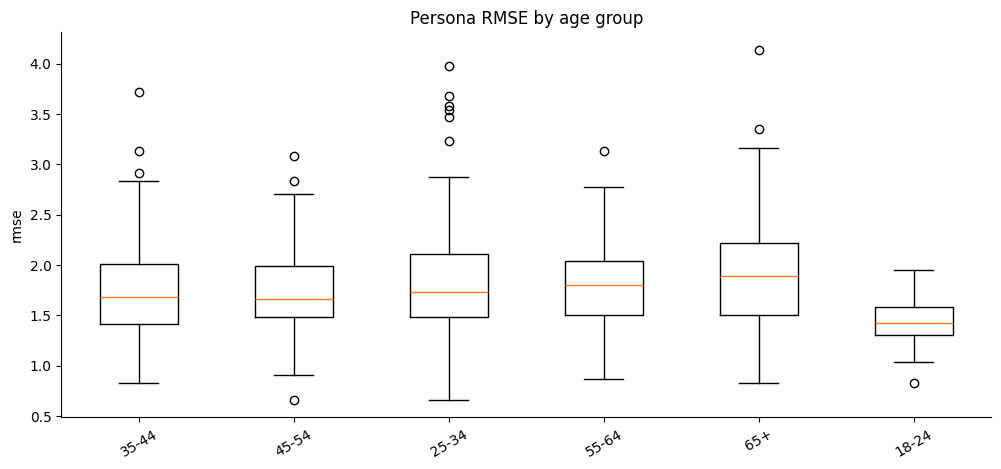

/tmp/ipykernel_3447/121038593.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(keep), vert=True)


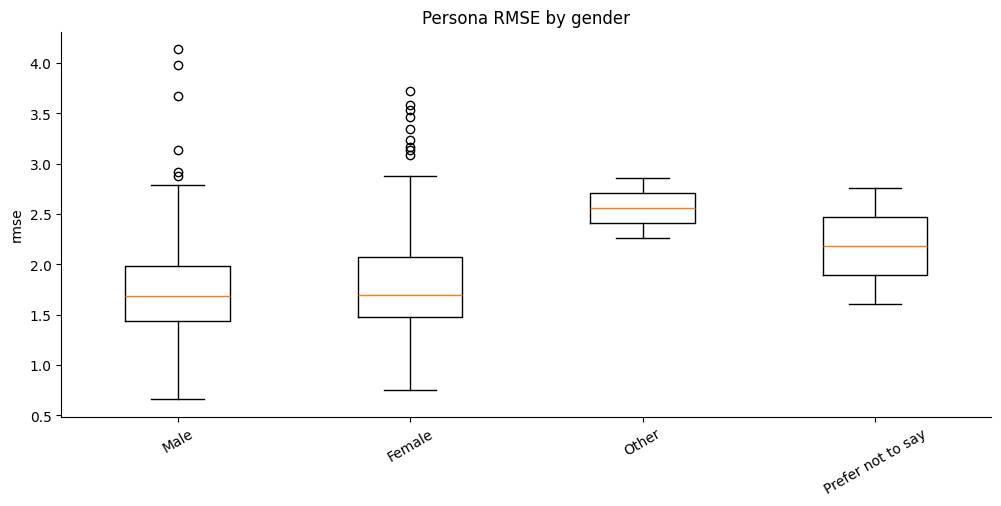

/tmp/ipykernel_3447/121038593.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(keep), vert=True)


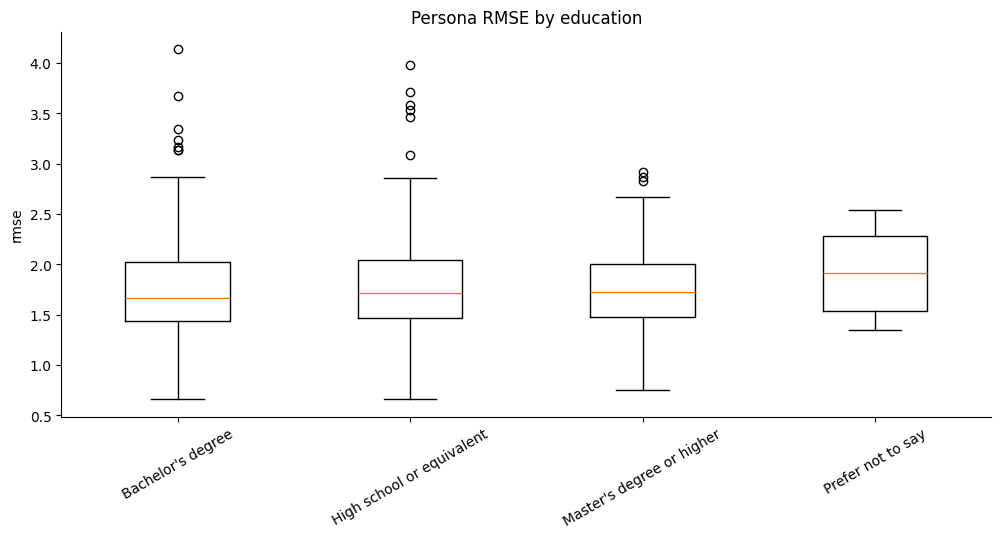

In [6]:

def simple_boxplot(df, group_col, value_col, title, max_groups=12):
    plot_df = df[[group_col, value_col]].dropna().copy()
    counts = plot_df[group_col].value_counts()
    keep = counts.head(max_groups).index
    plot_df = plot_df[plot_df[group_col].isin(keep)]
    groups = [plot_df.loc[plot_df[group_col] == g, value_col].values for g in keep]
    plt.figure(figsize=(12, 5))
    plt.boxplot(groups, labels=list(keep), vert=True)
    plt.title(title)
    plt.ylabel(value_col)
    plt.xticks(rotation=30)
    plt.show()

simple_boxplot(persona_df, "Q29", "rmse", "Persona RMSE by age group")
simple_boxplot(persona_df, "Q30", "rmse", "Persona RMSE by gender")
simple_boxplot(persona_df, "Q31", "rmse", "Persona RMSE by education")


## 4) Group-wise validation

This section compresses the results by demographic group:
- **Q29** = age
- **Q30** = gender
- **Q31** = education

This answers whether the model performs better for some population slices than others.


,group_column,group_value,group_size,compared,exact_match,macro_precision,macro_recall,macro_f1,weighted_f1,numeric_compared,mae,rmse,mean_actual,mean_predicted,mean_bias,pearson,spearman,tvd,js_divergence,group_label
0,Q29,18-24,12,204,0.260,0.215318,0.187029,0.187760,0.261,193,1.093,1.441,4.870466,4.844560,-0.026,0.606,0.575,0.230,0.090,Age
1,Q29,25-34,92,1564,0.231,0.238111,0.182913,0.179161,0.231,1472,1.478,1.985,4.446332,4.457201,0.011,0.352,0.370,0.215,0.104,Age
2,Q29,35-44,115,1955,0.245,0.248345,0.182456,0.180397,0.247,1843,1.346,1.801,4.548562,4.493760,-0.055,0.495,0.500,0.219,0.093,Age
3,Q29,45-54,98,1665,0.217,0.287197,0.179561,0.179344,0.225,1569,1.361,1.779,4.640535,4.500319,-0.140,0.506,0.503,0.241,0.102,Age
4,Q29,55-64,50,850,0.244,0.221491,0.181221,0.169923,0.247,801,1.413,1.899,4.626717,4.479401,-0.147,0.475,0.473,0.299,0.130,Age
5,Q29,65+,32,544,0.222,0.273582,0.185587,0.173145,0.251,514,1.580,2.077,4.599222,4.097276,-0.502,0.482,0.485,0.417,0.165,Age
6,Q30,Female,185,3144,0.228,0.213060,0.151872,0.149409,0.237,2964,1.432,1.909,4.687247,4.448381,-0.239,0.450,0.441,0.249,0.104,Gender
7,Q30,Male,210,3570,0.239,0.256889,0.177209,0.174614,0.241,3364,1.362,1.815,4.479191,4.468490,-0.011,0.486,0.498,0.241,0.108,Gender
8,Q30,Other,2,34,0.088,0.085227,0.065625,0.056250,0.084,32,2.156,2.580,4.531250,5.312500,0.781,0.100,-0.073,0.441,0.181,Gender
9,Q30,Prefer not to say,2,34,0.235,0.261806,0.201389,0.178770,0.233,32,1.656,2.257,3.531250,4.562500,1.031,0.428,0.416,0.294,0.149,Gender


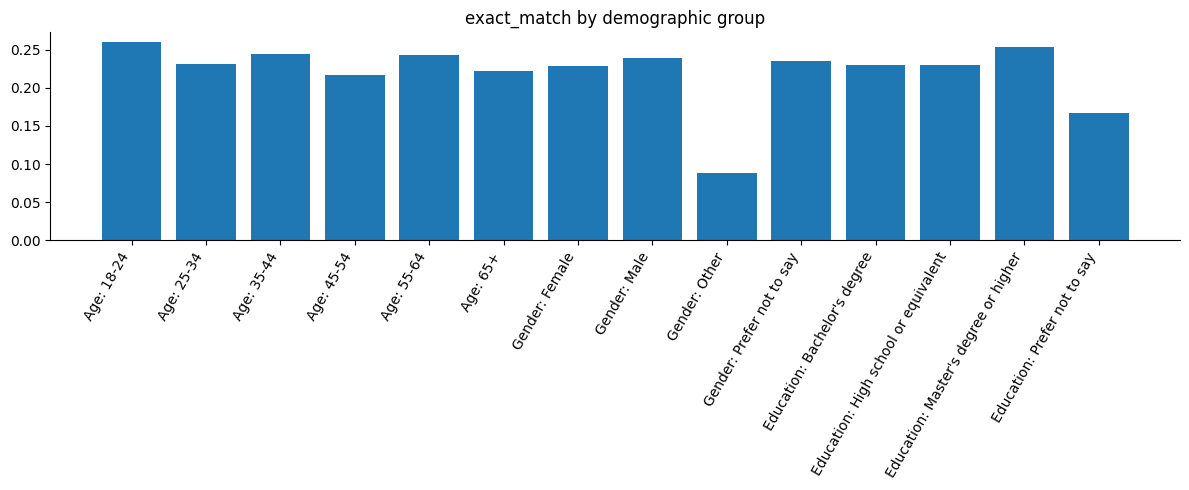

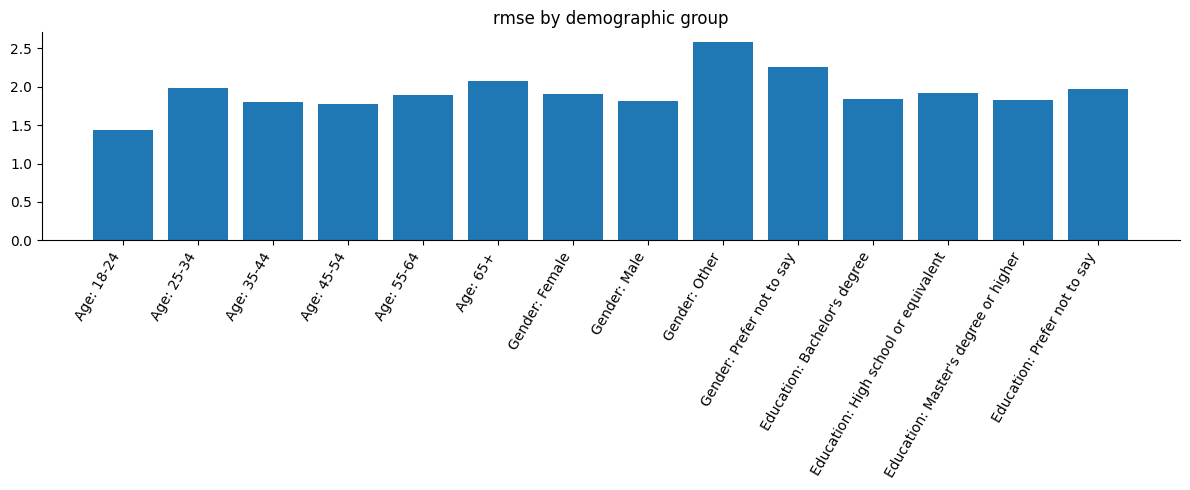

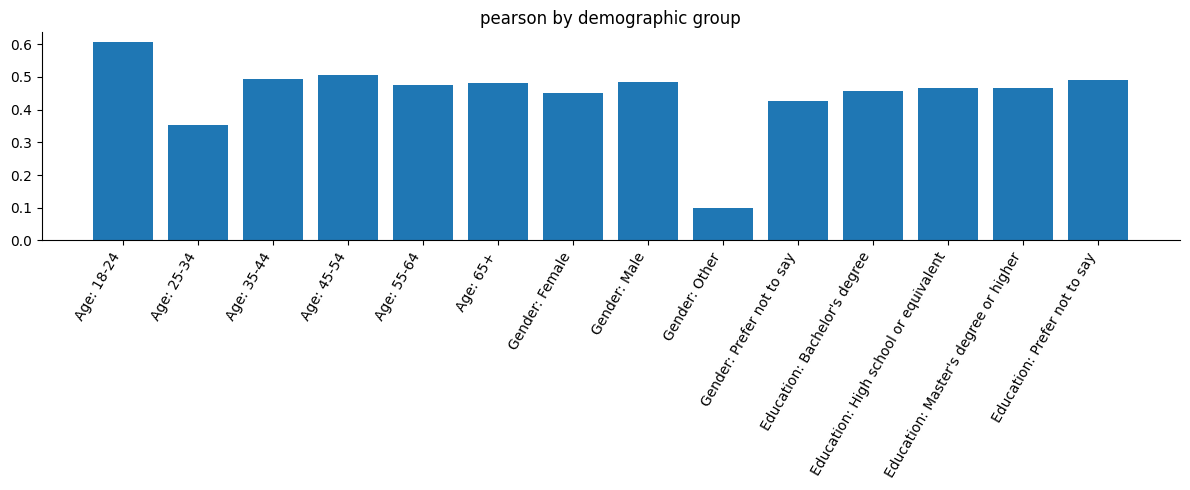

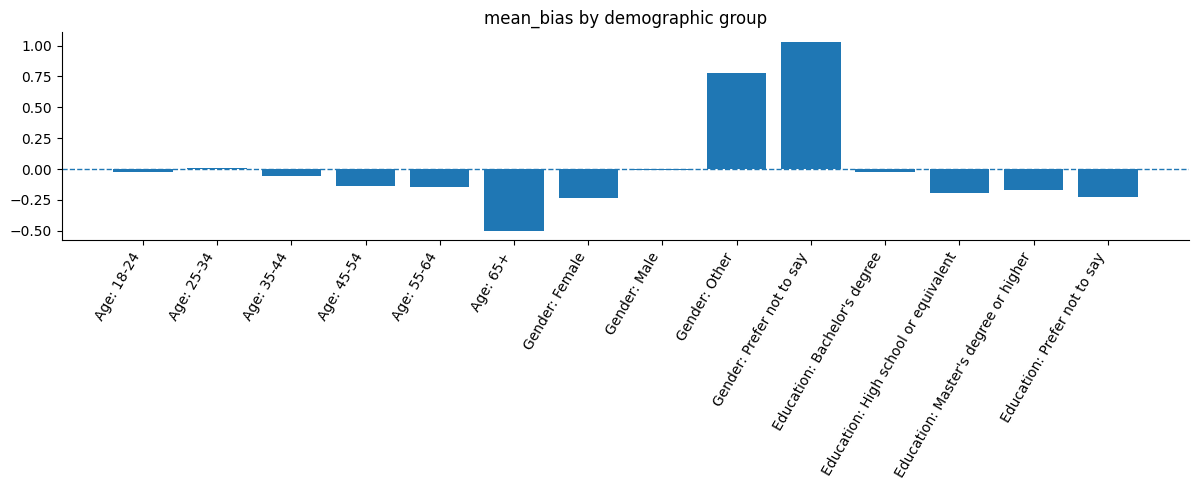

In [7]:

group_label_map = {"Q29": "Age", "Q30": "Gender", "Q31": "Education"}
group_df["group_label"] = group_df["group_column"].map(group_label_map).fillna(group_df["group_column"])

display(group_df.sort_values(["group_column", "group_value"]).style.format({
    "exact_match": "{:.3f}",
    "weighted_f1": "{:.3f}",
    "mae": "{:.3f}",
    "rmse": "{:.3f}",
    "mean_bias": "{:.3f}",
    "pearson": "{:.3f}",
    "spearman": "{:.3f}",
    "tvd": "{:.3f}",
    "js_divergence": "{:.3f}",
}))

for metric in ["exact_match", "rmse", "pearson", "mean_bias"]:
    plt.figure(figsize=(12, 5))
    plot_df = group_df.sort_values(["group_column", "group_value"]).copy()
    labels = plot_df["group_label"] + ": " + plot_df["group_value"].astype(str)
    plt.bar(labels, plot_df[metric])
    if metric == "mean_bias":
        plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{metric} by demographic group")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()


## 5) Group × question heatmaps

These heatmaps show where performance breaks down in a more detailed way.

Suggested reading:
- **Exact match heatmap**: where the model gets answers right most often
- **Bias heatmap**: where the model systematically predicts too high or too low
- **RMSE heatmap**: where the model misses badly even if averages look acceptable


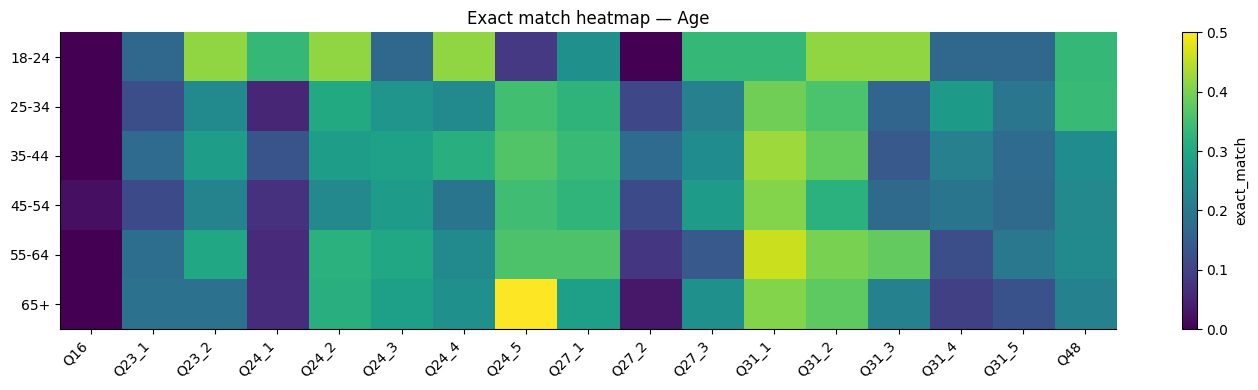

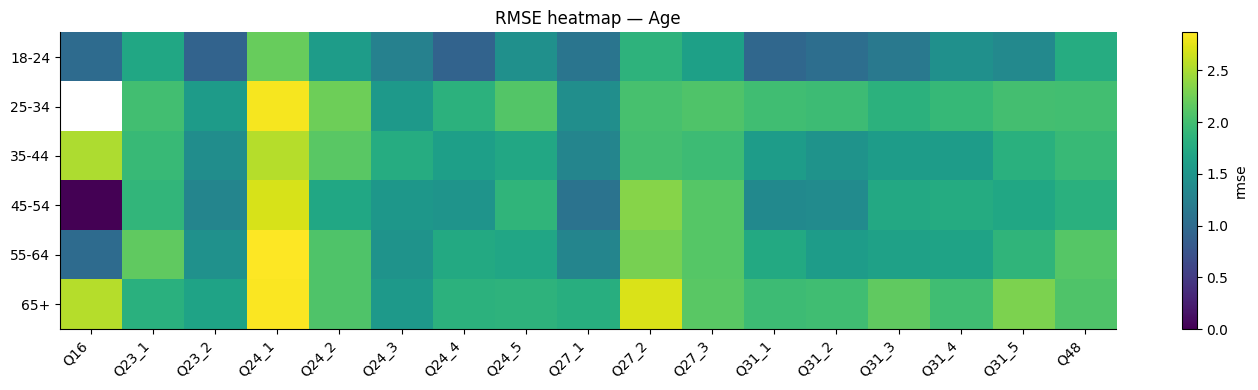

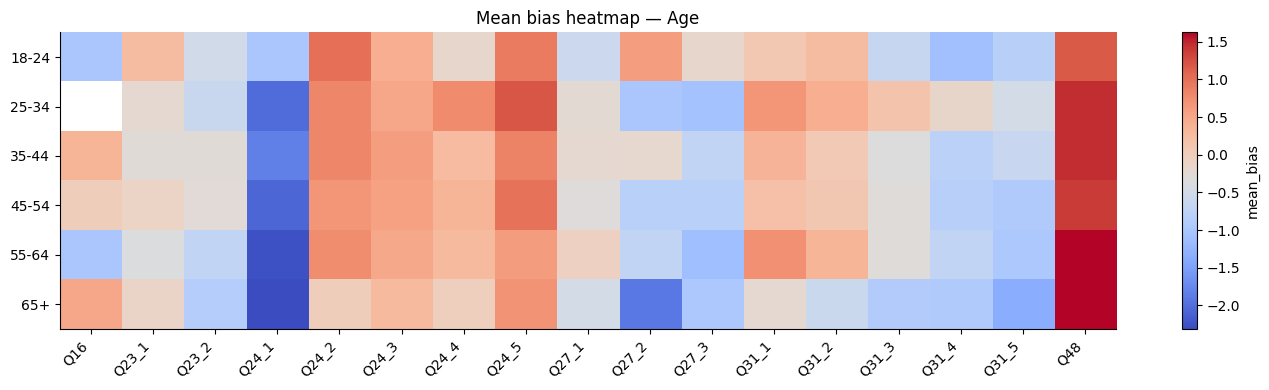

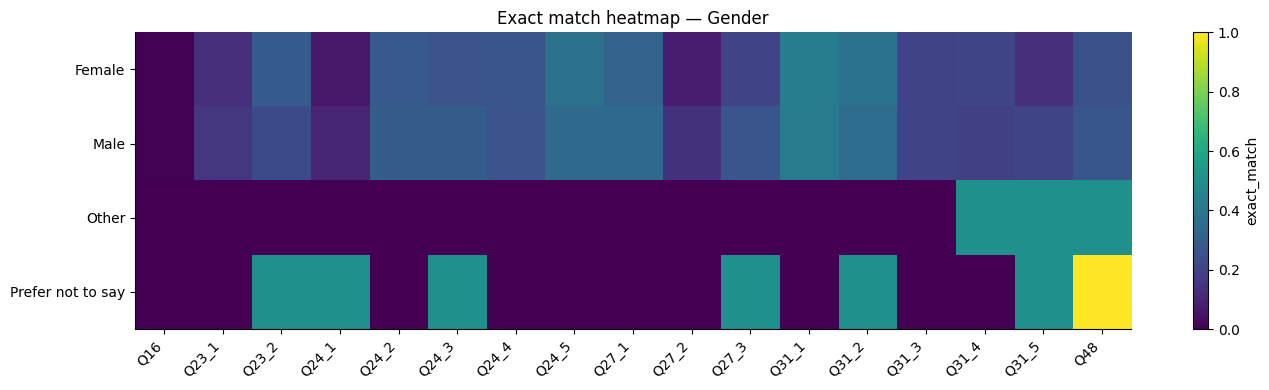

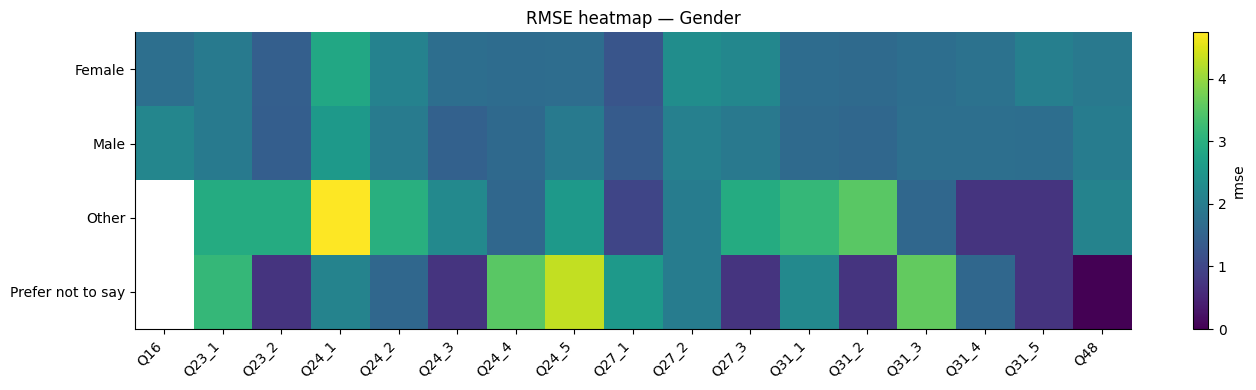

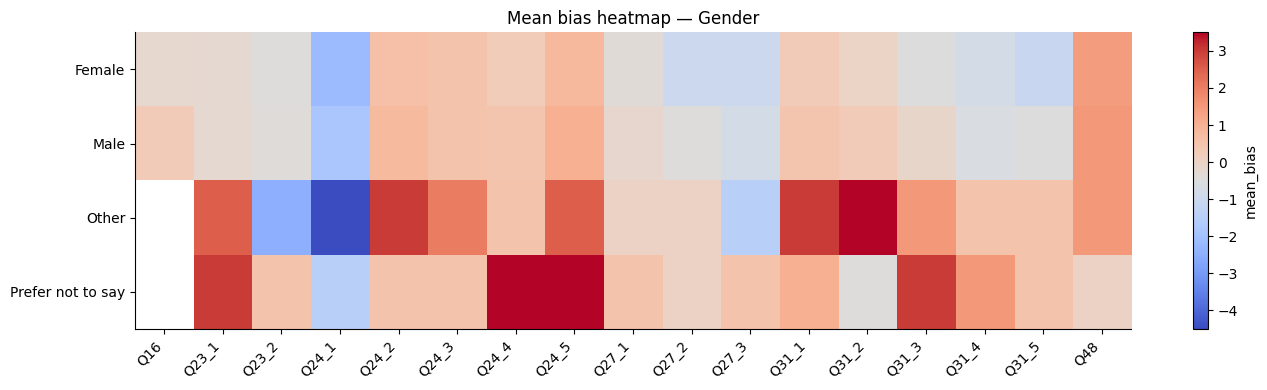

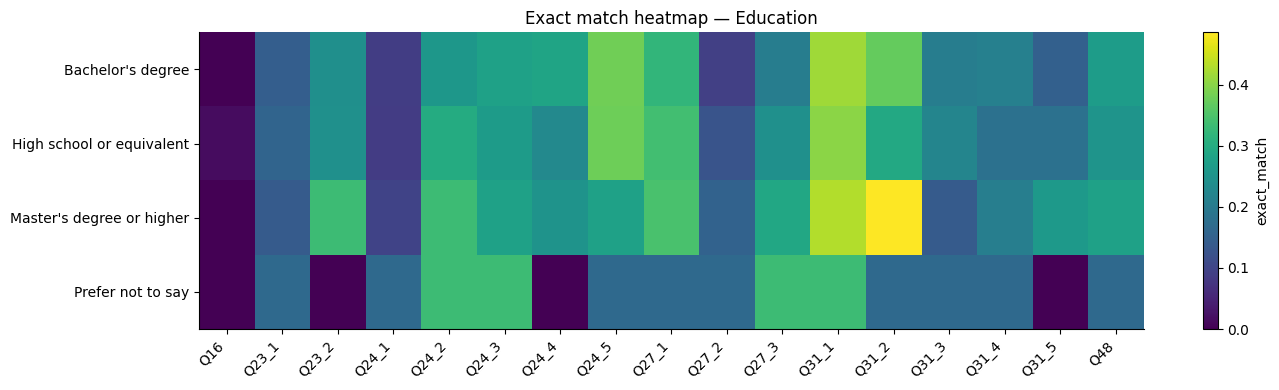

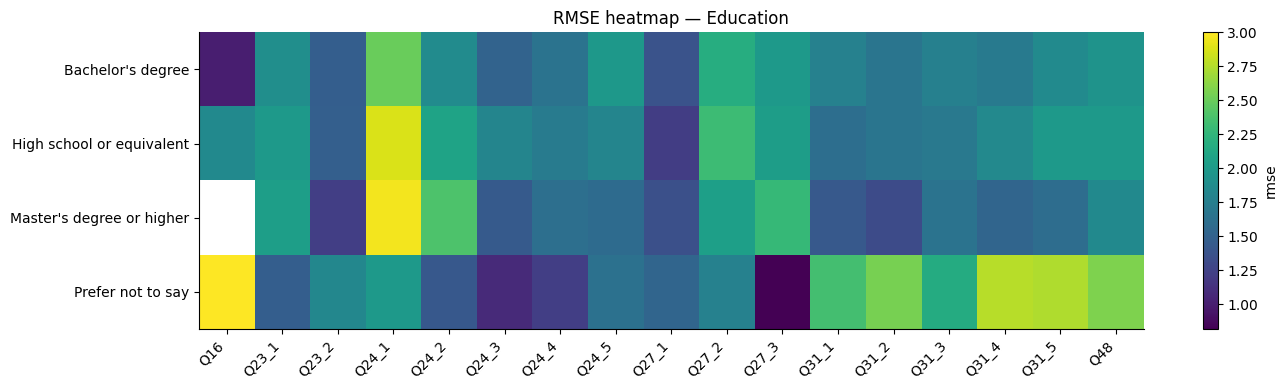

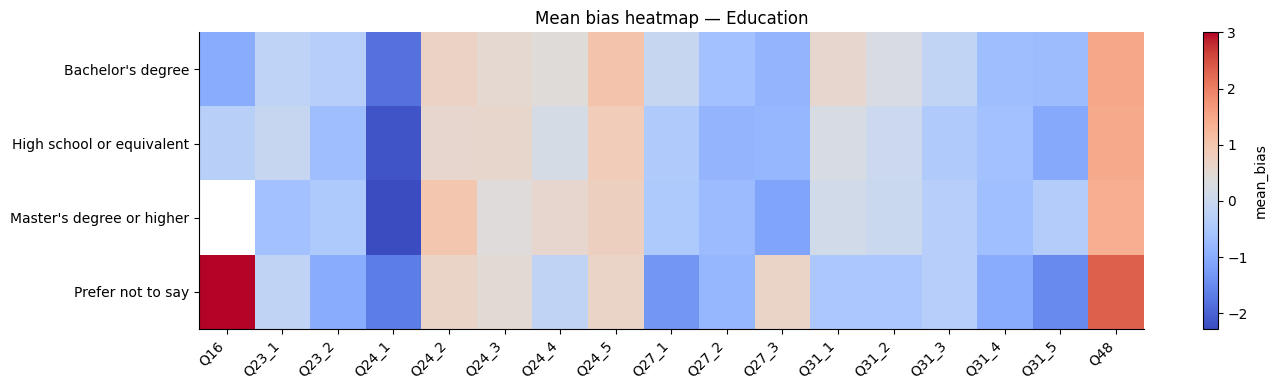

In [8]:

def plot_heatmap(df, value_col, group_column, title, cmap="viridis"):
    sub = df[df["group_column"] == group_column].copy()
    pivot = sub.pivot(index="group_value", columns="question", values=value_col)
    fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.5)))
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(value_col)
    plt.tight_layout()
    plt.show()

for group_column, label in [("Q29", "Age"), ("Q30", "Gender"), ("Q31", "Education")]:
    plot_heatmap(group_question_df, "exact_match", group_column, f"Exact match heatmap — {label}")
    plot_heatmap(group_question_df, "rmse", group_column, f"RMSE heatmap — {label}")
    plot_heatmap(group_question_df, "mean_bias", group_column, f"Mean bias heatmap — {label}", cmap="coolwarm")


## 6) Trend preservation across groups

A model can be weak on exact answers but still preserve **relative trends** across demographic groups.

This section checks:
- whether the predicted group means track the actual group means
- which questions preserve group structure well
- which questions distort the demographic pattern


,group_column,question,num_groups,mean_absolute_gap_across_groups,rmse_across_group_means,pearson_group_mean_correlation,spearman_group_mean_correlation
1,Q29,Q23_1,6,0.225,0.242,0.470,0.257
13,Q29,Q31_2,6,0.295,0.346,0.426,0.543
6,Q29,Q24_4,6,0.309,0.385,0.781,0.371
8,Q29,Q27_1,6,0.317,0.360,0.166,-0.200
12,Q29,Q31_1,6,0.374,0.444,0.575,0.771
11,Q29,Q16,5,0.442,0.577,-0.716,-0.667
14,Q29,Q31_3,6,0.448,0.516,0.568,0.486
5,Q29,Q24_3,6,0.470,0.481,0.977,0.771
2,Q29,Q23_2,6,0.544,0.585,-0.665,-0.600
4,Q29,Q24_2,6,0.674,0.745,0.370,0.314


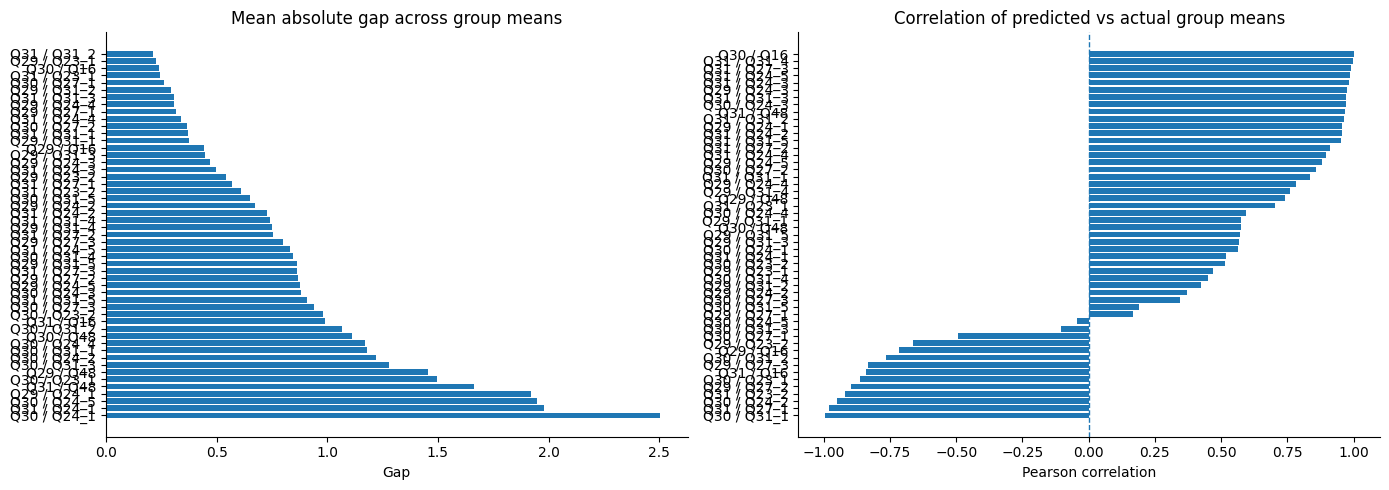

In [9]:

display(trend_df.sort_values(["group_column", "mean_absolute_gap_across_groups"]).style.format({
    "mean_absolute_gap_across_groups": "{:.3f}",
    "rmse_across_group_means": "{:.3f}",
    "pearson_group_mean_correlation": "{:.3f}",
    "spearman_group_mean_correlation": "{:.3f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tmp = trend_df.sort_values("mean_absolute_gap_across_groups", ascending=False)
axes[0].barh(
    tmp["group_column"] + " / " + tmp["question"],
    tmp["mean_absolute_gap_across_groups"]
)
axes[0].set_title("Mean absolute gap across group means")
axes[0].set_xlabel("Gap")

tmp = trend_df.sort_values("pearson_group_mean_correlation")
axes[1].barh(
    tmp["group_column"] + " / " + tmp["question"],
    tmp["pearson_group_mean_correlation"]
)
axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_title("Correlation of predicted vs actual group means")
axes[1].set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()


Worst preserved trends


,group_column,question,num_groups,mean_absolute_gap_across_groups,rmse_across_group_means,pearson_group_mean_correlation,spearman_group_mean_correlation
20,Q30,Q24_1,4,2.502606,2.765613,0.564708,0.2
37,Q31,Q24_1,4,1.979769,1.995514,0.519865,0.4
24,Q30,Q24_5,4,1.948649,2.243400,-0.042372,-0.6


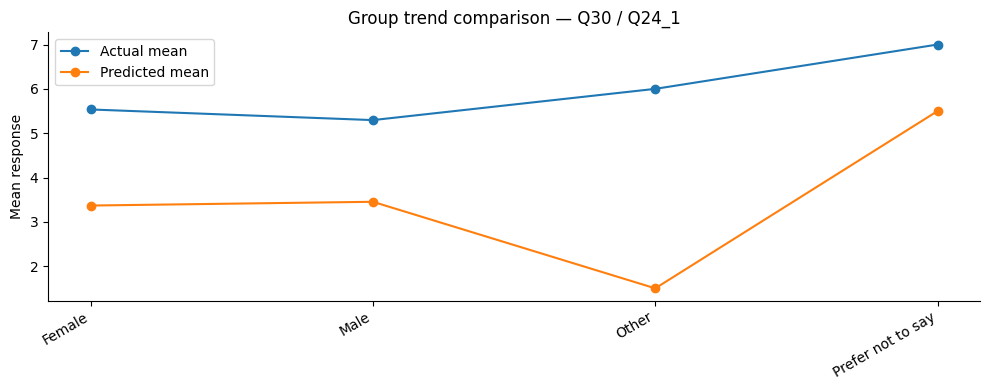

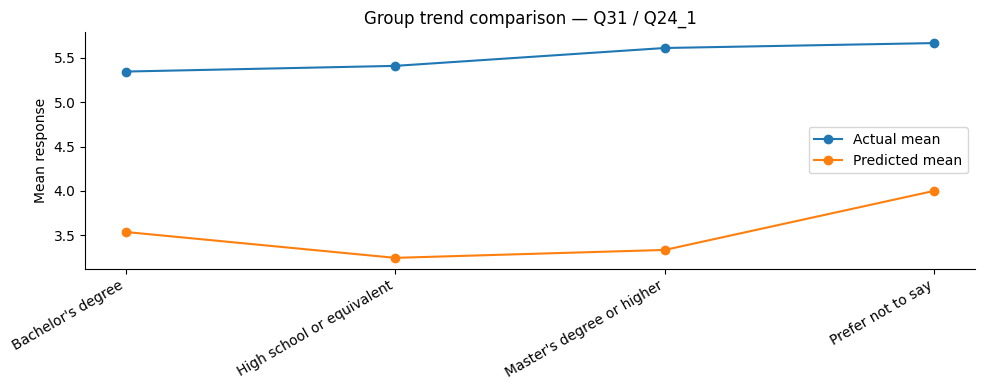

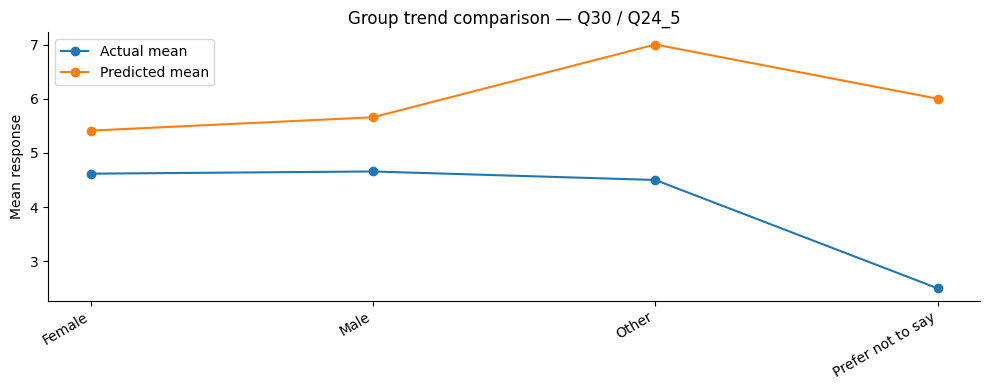

Best preserved trends


,group_column,question,num_groups,mean_absolute_gap_across_groups,rmse_across_group_means,pearson_group_mean_correlation,spearman_group_mean_correlation
47,Q31,Q31_2,4,0.211781,0.285153,0.962099,0.400000
1,Q29,Q23_1,6,0.225376,0.242413,0.470138,0.257143
28,Q30,Q16,2,0.237452,0.242307,1.000000,1.000000


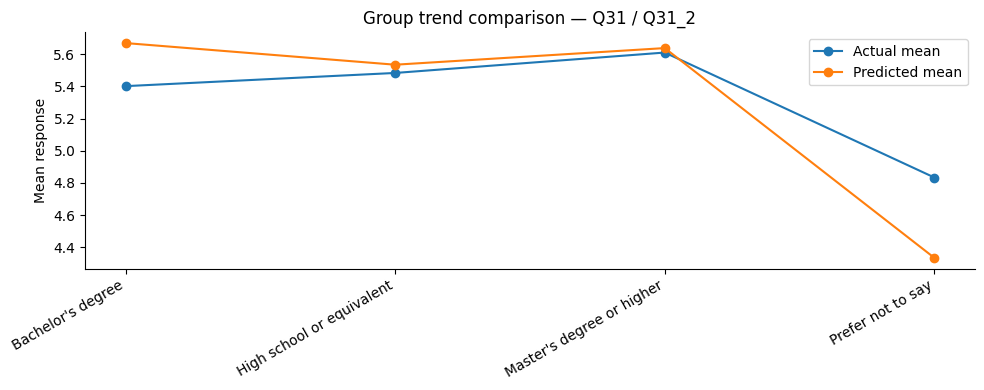

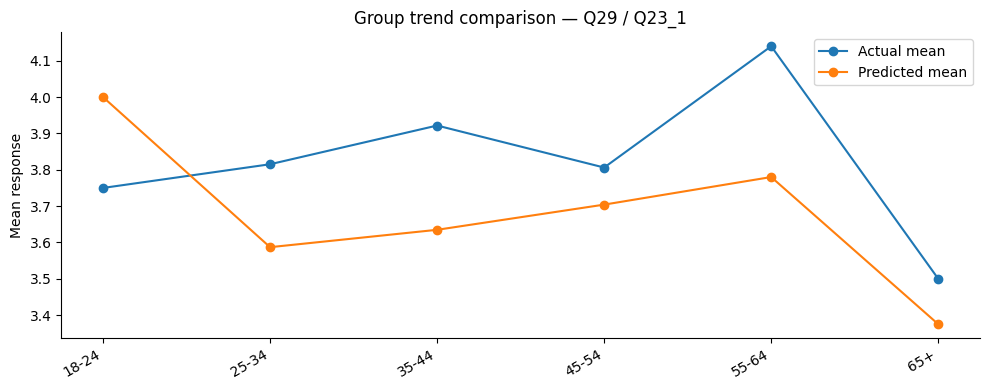

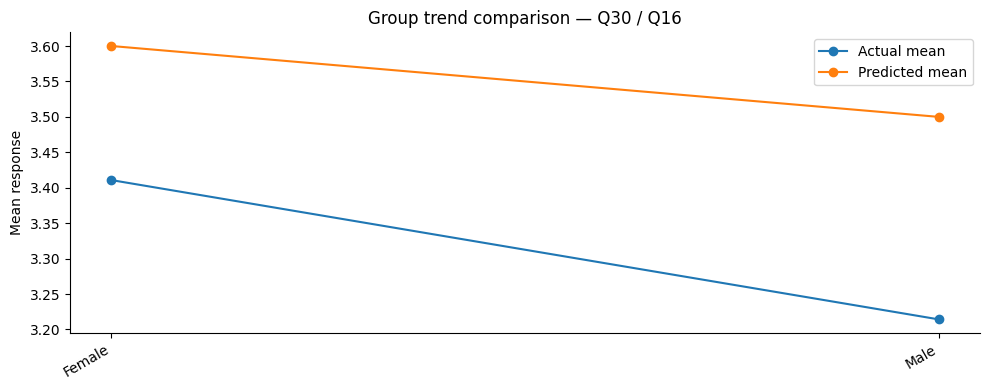

In [10]:

def plot_group_trend(question, group_column):
    sub = trend_detail_df[(trend_detail_df["question"] == question) & (trend_detail_df["group_column"] == group_column)].copy()
    if sub.empty:
        print(f"No data for question={question}, group_column={group_column}")
        return
    x = np.arange(len(sub))
    plt.figure(figsize=(10, 4))
    plt.plot(x, sub["actual_mean"], marker="o", label="Actual mean")
    plt.plot(x, sub["predicted_mean"], marker="o", label="Predicted mean")
    plt.xticks(x, sub["group_value"], rotation=30, ha="right")
    plt.title(f"Group trend comparison — {group_column} / {question}")
    plt.ylabel("Mean response")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Auto-select interesting examples:
worst_trends = trend_df.sort_values("mean_absolute_gap_across_groups", ascending=False).head(3)
best_trends = trend_df.sort_values("mean_absolute_gap_across_groups", ascending=True).head(3)

print("Worst preserved trends")
display(worst_trends)

for _, row in worst_trends.iterrows():
    plot_group_trend(row["question"], row["group_column"])

print("Best preserved trends")
display(best_trends)

for _, row in best_trends.iterrows():
    plot_group_trend(row["question"], row["group_column"])


## 7) Executive summary helper

This final cell creates a compact summary you can paste into slides or a report.


In [11]:

overall = summary["overall"]
best_question = question_df.sort_values("weighted_f1", ascending=False).iloc[0]
worst_question = question_df.sort_values("weighted_f1", ascending=True).iloc[0]
best_group = group_df.sort_values("exact_match", ascending=False).iloc[0]
worst_group = group_df.sort_values("exact_match", ascending=True).iloc[0]
worst_trend = trend_df.sort_values("mean_absolute_gap_across_groups", ascending=False).iloc[0]

report_lines = [
    "# Compact narrative summary",
    "",
    f"- The validation compares **{summary['num_personas']} personas** across **{summary['num_questions']} target questions**.",
    f"- Overall exact match is **{overall['exact_match']:.3f}** and weighted F1 is **{overall['weighted_f1']:.3f}**.",
    f"- Numeric error is **MAE {overall['mae']:.3f}** and **RMSE {overall['rmse']:.3f}**.",
    f"- Average bias is **{overall['mean_bias']:.3f}**, meaning predictions are slightly {'lower' if overall['mean_bias'] < 0 else 'higher'} than the survey answers on average.",
    f"- The strongest question by weighted F1 is **{best_question['question']}** ({best_question['weighted_f1']:.3f}).",
    f"- The weakest question by weighted F1 is **{worst_question['question']}** ({worst_question['weighted_f1']:.3f}).",
    f"- The best-performing demographic slice by exact match is **{best_group['group_column']} = {best_group['group_value']}** ({best_group['exact_match']:.3f}).",
    f"- The weakest-performing demographic slice by exact match is **{worst_group['group_column']} = {worst_group['group_value']}** ({worst_group['exact_match']:.3f}).",
    f"- The most distorted demographic trend is **{worst_trend['group_column']} / {worst_trend['question']}**, with mean absolute gap **{worst_trend['mean_absolute_gap_across_groups']:.3f}**.",
]
display(Markdown("\n".join(report_lines)))


# Compact narrative summary

- The validation compares **400 personas** across **17 target questions**.
- Overall exact match is **0.234** and weighted F1 is **0.238**.
- Numeric error is **MAE 1.400** and **RMSE 1.866**.
- Average bias is **-0.107**, meaning predictions are slightly lower than the survey answers on average.
- The strongest question by weighted F1 is **Q31_1** (0.394).
- The weakest question by weighted F1 is **Q16** (0.009).
- The best-performing demographic slice by exact match is **Q29 = 18-24** (0.260).
- The weakest-performing demographic slice by exact match is **Q30 = Other** (0.088).
- The most distorted demographic trend is **Q30 / Q24_1**, with mean absolute gap **2.503**.